Loading MNIST data...
Training on device: cuda

Starting Training with Custom Batch Normalization...

Epoch      | Train Loss   | Train Acc    | Test Loss    | Test Acc    
-----------------------------------------------------------------
Epoch 1    | 0.2362       | 93.82     % | 0.0882       | 97.32     %
Epoch 2    | 0.0903       | 97.22     % | 0.0736       | 97.66     %
Epoch 3    | 0.0667       | 97.94     % | 0.0619       | 98.00     %
Epoch 4    | 0.0504       | 98.41     % | 0.0643       | 97.91     %
Epoch 5    | 0.0414       | 98.61     % | 0.0661       | 97.93     %
Epoch 6    | 0.0344       | 98.90     % | 0.0677       | 98.03     %
Epoch 7    | 0.0305       | 99.00     % | 0.0549       | 98.31     %
Epoch 8    | 0.0270       | 99.13     % | 0.0660       | 98.13     %
Epoch 9    | 0.0228       | 99.27     % | 0.0668       | 98.06     %
Epoch 10   | 0.0208       | 99.28     % | 0.0707       | 98.17     %

Training complete!


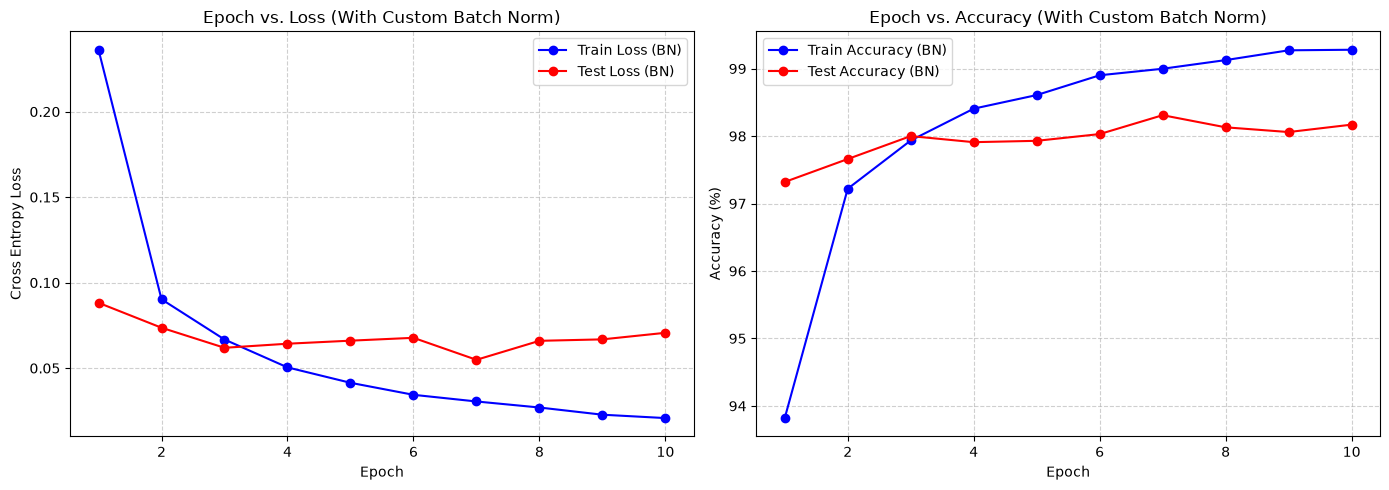

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

class CustomBatchNorm1d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super(CustomBatchNorm1d, self).__init__()
        self.eps = eps
        self.momentum = momentum
        
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))
        
    def forward(self, x):
        if self.training:
        
            batch_mean = x.mean(dim=0)
            batch_var = x.var(dim=0, unbiased=False)
            
       
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * batch_var
            
           
            x_normalized = (x - batch_mean) / torch.sqrt(batch_var + self.eps)
        else:
           
            x_normalized = (x - self.running_mean) / torch.sqrt(self.running_var + self.eps)
            
     
        return self.gamma * x_normalized + self.beta


print("Loading MNIST data...")
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on device: {device}")

train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

X_train = train_df.iloc[:, 1:].values / 255.0
y_train = train_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long) 
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)



model_bn = nn.Sequential(
    nn.Linear(784, 256),
    CustomBatchNorm1d(256),
    nn.ReLU(),
    
    nn.Linear(256, 128),
    CustomBatchNorm1d(128),
    nn.ReLU(),
    
    nn.Linear(128, 64),
    CustomBatchNorm1d(64),
    nn.ReLU(),
    
    nn.Linear(64, 10) 
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)


epochs = 10
print("\nStarting Training with Custom Batch Normalization...\n")
print(f"{'Epoch':<10} | {'Train Loss':<12} | {'Train Acc':<12} | {'Test Loss':<12} | {'Test Acc':<12}")
print("-" * 65)

train_losses_bn, train_accuracies_bn = [], []
test_losses_bn, test_accuracies_bn = [], []

for epoch in range(epochs):

    model_bn.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer_bn.zero_grad()
        outputs = model_bn(X_batch)
        
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_bn.step()
        
        running_train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
        
    avg_train_loss = running_train_loss / total_train
    train_acc = (correct_train / total_train) * 100

   
    model_bn.eval() 
    running_test_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad(): 
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model_bn(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_test_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()
            
    avg_test_loss = running_test_loss / total_test
    test_acc = (correct_test / total_test) * 100
    
    train_losses_bn.append(avg_train_loss)
    train_accuracies_bn.append(train_acc)
    test_losses_bn.append(avg_test_loss)
    test_accuracies_bn.append(test_acc)
    
    print(f"Epoch {epoch+1:<4} | {avg_train_loss:<12.4f} | {train_acc:<10.2f}% | {avg_test_loss:<12.4f} | {test_acc:<10.2f}%")

print("\nTraining complete!")


plt.figure(figsize=(14, 5))
epochs_range = range(1, epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_bn, label='Train Loss (BN)', color='blue', marker='o')
plt.plot(epochs_range, test_losses_bn, label='Test Loss (BN)', color='red', marker='o')
plt.title('Epoch vs. Loss (With Custom Batch Norm)')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies_bn, label='Train Accuracy (BN)', color='blue', marker='o')
plt.plot(epochs_range, test_accuracies_bn, label='Test Accuracy (BN)', color='red', marker='o')
plt.title('Epoch vs. Accuracy (With Custom Batch Norm)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()